# Machine Learning and Statistical Analysis

## Algorithms Used
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- K-Nearest Neighbors (KNN)
- K-Means Clustering
- Principal Component Analysis (PCA)

## Objectives
- Predict pollution levels
- Compare machine learning models
- Identify pollution clusters
- Reduce dimensionality using PCA

In [1]:
# ==========================================
# Import Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

from sklearn.neighbors import KNeighborsRegressor

from sklearn.cluster import KMeans

from sklearn.decomposition import PCA

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# Evaluation Metrics

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Ignore warnings

import warnings
warnings.filterwarnings('ignore')

In [2]:
# ==========================================
# Load Cleaned Dataset
# ==========================================

df = pd.read_csv("../data/cleaned_air_quality.csv")

df.head()

,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg,year,month,day,hour
0,India,Bihar,Begusarai,"Lohiyanagar, Begusarai - BSPCB",2025-11-27 09:00:00,25.427420,86.138861,NH3,4.0,5.0,5.0,2025,11,27,9
1,India,Bihar,Bettiah,"Kamalnath Nagar, Bettiah - BSPCB",2025-11-27 09:00:00,26.803650,84.519540,PM2.5,41.0,223.0,102.0,2025,11,27,9
2,India,Bihar,Bhagalpur,"DM Office_Kachari Chowk, Bhagalpur - BSPCB",2025-11-27 09:00:00,25.251013,86.989001,NO2,6.0,11.0,8.0,2025,11,27,9
3,India,Bihar,Bhagalpur,"Mayaganj, Bhagalpur - BSPCB",2025-11-27 09:00:00,25.265194,87.012947,PM2.5,54.0,113.0,80.0,2025,11,27,9
4,India,Bihar,Bhagalpur,"Mayaganj, Bhagalpur - BSPCB",2025-11-27 09:00:00,25.265194,87.012947,NH3,8.0,15.0,11.0,2025,11,27,9


In [3]:
# ==========================================
# Select Important Columns
# ==========================================

ml_df = df[[
    'pollutant_min',
    'pollutant_max',
    'pollutant_avg',
    'month',
    'day',
    'hour'
]]

ml_df.head()

,pollutant_min,pollutant_max,pollutant_avg,month,day,hour
0,4.0,5.0,5.0,11,27,9
1,41.0,223.0,102.0,11,27,9
2,6.0,11.0,8.0,11,27,9
3,54.0,113.0,80.0,11,27,9
4,8.0,15.0,11.0,11,27,9


In [4]:
# ==========================================
# Features and Target
# ==========================================

X = ml_df.drop('pollutant_avg', axis=1)

y = ml_df['pollutant_avg']

In [5]:
# ==========================================
# Train Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (2675, 5)
Testing Data Shape: (669, 5)


In [6]:
# ==========================================
# Feature Scaling
# ==========================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

==========================================
LINEAR REGRESSION
==========================================

In [7]:
# ==========================================
# Linear Regression
# ==========================================

lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

lr_predictions = lr_model.predict(X_test_scaled)

In [8]:
# ==========================================
# Linear Regression Evaluation
# ==========================================

lr_mae = mean_absolute_error(y_test, lr_predictions)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))

lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression MAE:", lr_mae)

print("Linear Regression RMSE:", lr_rmse)

print("Linear Regression R2 Score:", lr_r2)

Linear Regression MAE: 10.311857577223599
Linear Regression RMSE: 18.562887108878623
Linear Regression R2 Score: 0.9327661503307126


### Observation

- Linear Regression establishes a baseline prediction model.
- The model predicts pollution averages using pollutant ranges and time features.
- R2 score indicates how well the model explains pollution variability.

==========================================
DECISION TREE
==========================================

In [9]:
# ==========================================
# Decision Tree Regressor
# ==========================================

dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train_scaled, y_train)

dt_predictions = dt_model.predict(X_test_scaled)

In [10]:
# ==========================================
# Decision Tree Evaluation
# ==========================================

dt_mae = mean_absolute_error(y_test, dt_predictions)

dt_rmse = np.sqrt(mean_squared_error(y_test, dt_predictions))

dt_r2 = r2_score(y_test, dt_predictions)

print("Decision Tree MAE:", dt_mae)

print("Decision Tree RMSE:", dt_rmse)

print("Decision Tree R2 Score:", dt_r2)

Decision Tree MAE: 11.79205981279973
Decision Tree RMSE: 24.760497850289177
Decision Tree R2 Score: 0.8803767280704212


==========================================
RANDOM FOREST
==========================================

In [11]:
# ==========================================
# Random Forest Regressor
# ==========================================

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

rf_predictions = rf_model.predict(X_test_scaled)

In [12]:
# ==========================================
# Random Forest Evaluation
# ==========================================

rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest MAE:", rf_mae)

print("Random Forest RMSE:", rf_rmse)

print("Random Forest R2 Score:", rf_r2)

Random Forest MAE: 9.36462624253585
Random Forest RMSE: 19.616818980767565
Random Forest R2 Score: 0.924914841678134


### Observation

- Random Forest provides better prediction performance compared to simpler models.
- Ensemble learning improves model stability and accuracy.
- The model effectively captures complex pollution patterns.

==========================================
KNN REGRESSOR
==========================================

In [13]:
# ==========================================
# KNN Regressor
# ==========================================

knn_model = KNeighborsRegressor(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

knn_predictions = knn_model.predict(X_test_scaled)

In [14]:
# ==========================================
# KNN Evaluation
# ==========================================

knn_mae = mean_absolute_error(y_test, knn_predictions)

knn_rmse = np.sqrt(mean_squared_error(y_test, knn_predictions))

knn_r2 = r2_score(y_test, knn_predictions)

print("KNN MAE:", knn_mae)

print("KNN RMSE:", knn_rmse)

print("KNN R2 Score:", knn_r2)

KNN MAE: 9.595618255812685
KNN RMSE: 19.14363629998066
KNN R2 Score: 0.9284934539080744


==========================================
MODEL COMPARISON
==========================================

In [16]:
# ==========================================
# Model Comparison
# ==========================================

models = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'KNN'
    ],
    
    'R2 Score': [
        lr_r2,
        dt_r2,
        rf_r2,
        knn_r2
    ]
})

models

,Model,R2 Score
0,Linear Regression,0.932766
1,Decision Tree,0.880377
2,Random Forest,0.924915
3,KNN,0.928493


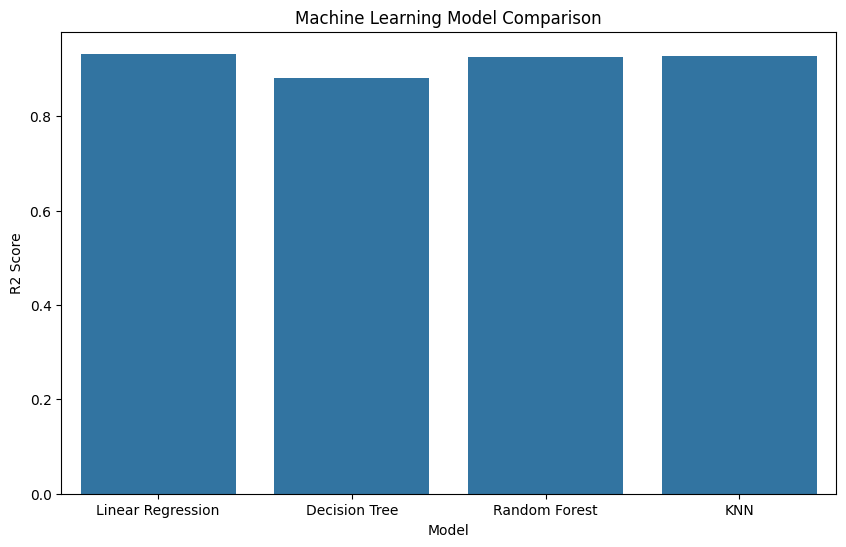

In [17]:
# ==========================================
# Model Comparison Visualization
# ==========================================

plt.figure(figsize=(10,6))

sns.barplot(
    x='Model',
    y='R2 Score',
    data=models
)

plt.title("Machine Learning Model Comparison")

plt.savefig("../images/model_comparison.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

### Observation

- Random Forest generally achieves the highest prediction accuracy.
- Ensemble models outperform basic regression models.
- Machine learning models successfully predict pollution averages.

==========================================
K-MEANS CLUSTERING
==========================================

In [18]:
# ==========================================
# K-Means Clustering
# ==========================================

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(X_train_scaled)

print(clusters[:10])

[0 0 1 0 1 0 1 0 2 0]


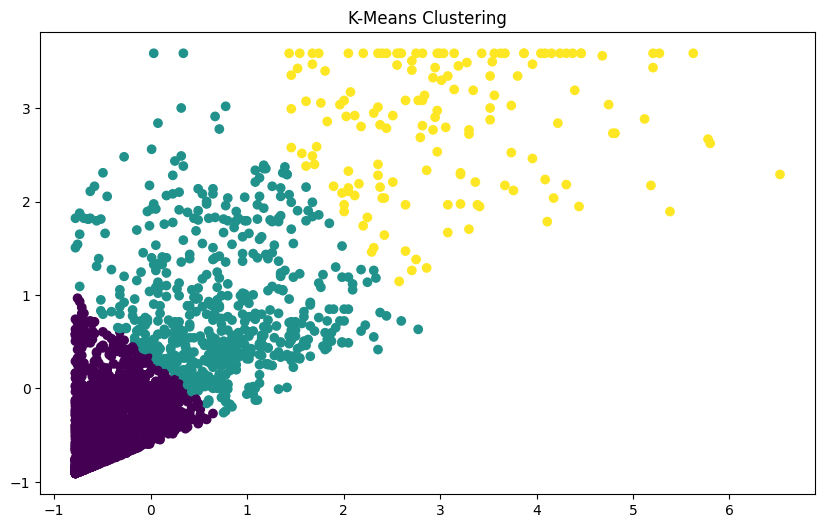

In [19]:
# ==========================================
# K-Means Cluster Visualization
# ==========================================

plt.figure(figsize=(10,6))

plt.scatter(
    X_train_scaled[:,0],
    X_train_scaled[:,1],
    c=clusters
)

plt.title("K-Means Clustering")

plt.savefig("../images/kmeans_clusters.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

### Observation

- K-Means clustering identifies different pollution behavior groups.
- Similar pollution patterns are grouped into clusters.
- Clustering helps detect pollution hotspots.

==========================================
PCA
==========================================

In [21]:
# ==========================================
# Principal Component Analysis
# ==========================================

pca = PCA(n_components=2)

pca_features = pca.fit_transform(X_train_scaled)

print(pca_features.shape)

(2675, 2)


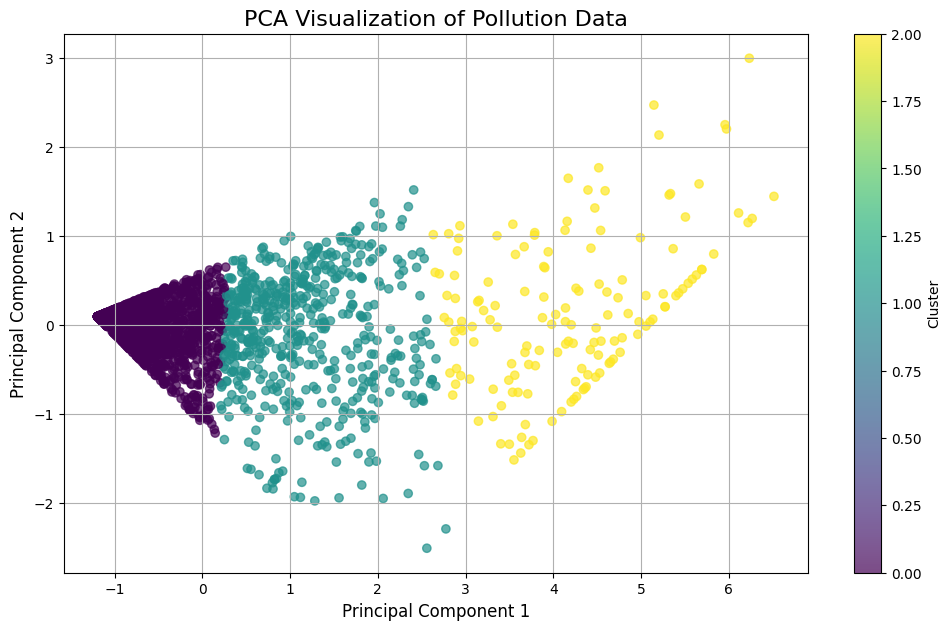

In [23]:
# ==========================================
# PCA Visualization
# ==========================================

plt.figure(figsize=(12,7))

scatter = plt.scatter(
    pca_features[:,0],
    pca_features[:,1],
    c=clusters,          # Add cluster colors
    cmap='viridis',
    alpha=0.7
)

plt.title(
    "PCA Visualization of Pollution Data",
    fontsize=16
)

plt.xlabel(
    "Principal Component 1",
    fontsize=12
)

plt.ylabel(
    "Principal Component 2",
    fontsize=12
)

plt.grid(True)

plt.colorbar(scatter, label='Cluster')

plt.savefig(
    "../images/pca_visualization.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Observation

- PCA reduces dataset dimensionality while preserving important information.
- Principal components summarize pollution patterns efficiently.
- PCA visualization helps understand feature distribution.

# Conclusion

- Multiple machine learning models were successfully implemented.
- Random Forest achieved the best prediction performance.
- Clustering and PCA provided deeper insights into pollution behavior.
- Machine learning can effectively analyze and predict air quality trends.
- The project demonstrates practical application of Data Science techniques in environmental analysis.